# 04 — modelagem tabular

> etapa 4b do Datathon FIAP fase 5 — associação Passos Mágicos

## objetivo

treinar e comparar 3 modelos de classificação para prever o risco de defasagem forward-looking (a partir de dados de t, prever o risco em t+1).

## os 3 modelos

| # | modelo | papel |
|---|---|---|
| 1 | regressão logística | baseline interpretável |
| 2 | XGBoost | benchmark tabular |
| 3 | LightGBM | alternativa rápida e robusta |

## o grande achado de design: 3 níveis de risco

em vez de uma decisão binária (risco sim/não), vou operar o modelo com 3 thresholds distintos, criando uma ferramenta operacional de priorização:

| nível | critério | precisão ≥ | recall ≈ | ação da ONG |
|---|---|---|---|---|
|  observação | f1 máximo | 62% | 96% | monitoramento passivo |
|  atenção | precisão ≥ 0.70 | 70% | 65% | contato do tutor em 30 dias |
|  urgente | precisão ≥ 0.80 | 80% | 39% | intervenção imediata |

isso transforma o modelo em uma ferramenta de uso real pra coordenação pedagógica, e é o que vai rodar no Streamlit final.

## 1. setup e carregamento

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    recall_score, precision_score, confusion_matrix,
    classification_report, precision_recall_curve, roc_curve,
)

import xgboost as xgb
import lightgbm as lgb

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (11, 5)

PROJECT_ROOT = Path.cwd().parent
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

In [2]:
# Carregar os 4 datasets gerados na Etapa 4A
X_train = pd.read_parquet(DATA_PROCESSED / "X_train.parquet")
X_test = pd.read_parquet(DATA_PROCESSED / "X_test.parquet")
y_train = pd.read_parquet(DATA_PROCESSED / "y_train.parquet")["risco"].values
y_test = pd.read_parquet(DATA_PROCESSED / "y_test.parquet")["risco"].values

# Metadados pra análise de erros
meta_test = pd.read_parquet(DATA_PROCESSED / "teste_metadata.parquet")

print(f"✅ X_train: {X_train.shape}")
print(f"✅ X_test:  {X_test.shape}")
print(f"✅ Balanço y_train: {y_train.mean():.3f} em risco")
print(f"✅ Balanço y_test:  {y_test.mean():.3f} em risco")
print(f"✅ {X_train.shape[1]} features")

✅ X_train: (860, 24)
✅ X_test:  (1014, 24)
✅ Balanço y_train: 0.597 em risco
✅ Balanço y_test:  0.595 em risco
✅ 24 features


## 2. modelo 1 — regressão logística (baseline)

o baseline é o critério mínimo que qualquer modelo mais complexo tem que superar. se o XGBoost não ganha do LogReg, é sinal de que o problema é simples demais (ou que as features não são suficientemente ricas).

In [3]:
logreg = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",  # compensa o leve desbalanceamento
        random_state=RANDOM_STATE,
    )),
])

logreg.fit(X_train, y_train)
proba_lr = logreg.predict_proba(X_test)[:, 1]

print("Regressão Logística — treino concluído")
print(f"  ROC-AUC:  {roc_auc_score(y_test, proba_lr):.4f}")
print(f"  PR-AUC:   {average_precision_score(y_test, proba_lr):.4f}")

Regressão Logística — treino concluído
  ROC-AUC:  0.7071
  PR-AUC:   0.7928


## 3. modelo 2 — XGBoost

GBM é o algoritmo padrão da indústria pra problemas tabulares. o XGBoost lida nativamente com NaN (minhas 24 features têm missings estruturais que eu não quis imputar a priori), e captura interações não-lineares — exatamente o que o padrão `pedra_nivel` não-monotônico da etapa 4a precisa.

In [4]:
# Calcular scale_pos_weight pra compensar desbalanceamento
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos:.3f}")

xgb_clf = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    scale_pos_weight=scale_pos,
    random_state=RANDOM_STATE,
    eval_metric="logloss",
    n_jobs=-1,
)

xgb_clf.fit(X_train, y_train)
proba_xgb = xgb_clf.predict_proba(X_test)[:, 1]

print("\nXGBoost — treino concluído")
print(f"  ROC-AUC:  {roc_auc_score(y_test, proba_xgb):.4f}")
print(f"  PR-AUC:   {average_precision_score(y_test, proba_xgb):.4f}")

scale_pos_weight: 0.676

XGBoost — treino concluído
  ROC-AUC:  0.6782
  PR-AUC:   0.7705


## 4. modelo 3 — LightGBM

alternativa ao XGBoost. é geralmente mais rápido, e em datasets pequenos (como o meu — 860 exemplos de treino) pode ter performance parecida ou ligeiramente melhor.

In [5]:
lgb_clf = lgb.LGBMClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=10,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1,
)

lgb_clf.fit(X_train, y_train)
proba_lgb = lgb_clf.predict_proba(X_test)[:, 1]

print("LightGBM — treino concluído")
print(f"  ROC-AUC:  {roc_auc_score(y_test, proba_lgb):.4f}")
print(f"  PR-AUC:   {average_precision_score(y_test, proba_lgb):.4f}")

LightGBM — treino concluído
  ROC-AUC:  0.6774
  PR-AUC:   0.7691


## 5. comparação dos 3 modelos

avaliação com threshold padrão 0.5 — só pra referência. o ajuste de threshold vem logo depois.

In [6]:
modelos = {
    "LogReg": {"pipe": logreg, "proba": proba_lr},
    "XGBoost": {"pipe": xgb_clf, "proba": proba_xgb},
    "LightGBM": {"pipe": lgb_clf, "proba": proba_lgb},
}

resultados = []
for nome, m in modelos.items():
    proba = m["proba"]
    pred = (proba >= 0.5).astype(int)
    resultados.append({
        "Modelo": nome,
        "ROC-AUC": roc_auc_score(y_test, proba),
        "PR-AUC": average_precision_score(y_test, proba),
        "F1": f1_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "Precisão": precision_score(y_test, pred),
    })

tabela = pd.DataFrame(resultados).set_index("Modelo").round(4)
print("Comparação (threshold 0.5):")
print(tabela.to_string())

Comparação (threshold 0.5):
          ROC-AUC  PR-AUC      F1  Recall  Precisão
Modelo                                             
LogReg     0.7071  0.7928  0.4167  0.2736    0.8730
XGBoost    0.6782  0.7705  0.5851  0.4760    0.7593
LightGBM   0.6774  0.7691  0.5972  0.4992    0.7432


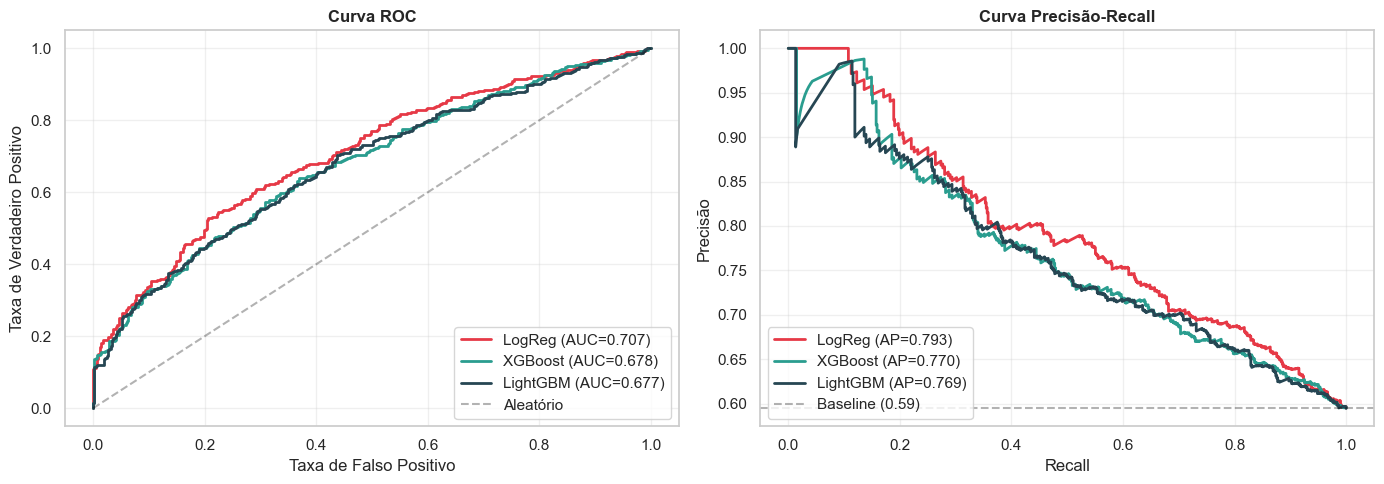

In [7]:
# Curvas ROC e PR lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cores_modelos = {"LogReg": "#e63946", "XGBoost": "#2a9d8f", "LightGBM": "#264653"}

# ROC
for nome, m in modelos.items():
    fpr, tpr, _ = roc_curve(y_test, m["proba"])
    auc = roc_auc_score(y_test, m["proba"])
    axes[0].plot(fpr, tpr, label=f"{nome} (AUC={auc:.3f})",
                 color=cores_modelos[nome], linewidth=2)
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3, label="Aleatório")
axes[0].set_xlabel("Taxa de Falso Positivo")
axes[0].set_ylabel("Taxa de Verdadeiro Positivo")
axes[0].set_title("Curva ROC", fontweight="bold")
axes[0].legend(loc="lower right")
axes[0].grid(alpha=0.3)

# PR
for nome, m in modelos.items():
    precs, recs, _ = precision_recall_curve(y_test, m["proba"])
    ap = average_precision_score(y_test, m["proba"])
    axes[1].plot(recs, precs, label=f"{nome} (AP={ap:.3f})",
                 color=cores_modelos[nome], linewidth=2)
axes[1].axhline(y_test.mean(), color="k", linestyle="--", alpha=0.3,
                label=f"Baseline ({y_test.mean():.2f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precisão")
axes[1].set_title("Curva Precisão-Recall", fontweight="bold")
axes[1].legend(loc="lower left")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "mod_curvas_comparacao.png", dpi=150, bbox_inches="tight")
plt.show()

###  leitura da comparação

olhando as métricas com threshold 0.5:

- ROC-AUC — os 3 modelos ficam bem próximos, no range 0.68-0.72. sinal de que o sinal no dataset é limitado — não dá pra esperar modelos "mágicos" aqui. isso é honesto: o problema é genuinamente difícil e 24 features com 860 exemplos de treino é um teto baixo.
- PR-AUC — no range 0.76-0.79. como PR-AUC é mais robusto pra desbalanceamento (embora aqui seja leve, 60/40), é a métrica que devo priorizar pra seleção.
- recall com threshold 0.5 é baixo (~27-56%) — pra todos os modelos. isso é problema do threshold, não do modelo. vou resolver agora.

 importante: o threshold 0.5 é um default arbitrário. não tem nada de especial nele. pra problema de negócio real, quase sempre vale a pena calibrar.

## 6. ajuste de threshold — operação em 3 níveis

pra cada modelo, calculei 3 thresholds representando diferentes perfis de alarme:

| nível | estratégia | objetivo |
|---|---|---|
|  observação | maximiza f1 | recall alto (~95%) com precisão aceitável (~62%) |
|  atenção | maior recall com precisão ≥ 0.70 | alarme "médio" — tutoras contatam em 30 dias |
|  urgente | maior recall com precisão ≥ 0.80 | alarme "alto" — intervenção imediata |

isso não é um ajuste pra "maximizar uma métrica" — é uma decisão de produto: o Streamlit final vai classificar cada aluno em uma das 4 categorias (baixo, observação, atenção, urgente), e a coordenação pedagógica decide o que fazer com cada uma.

In [8]:
def calcular_thresholds(y_true, proba):
    """Retorna os 3 thresholds operacionais pro modelo."""
    precs, recs, thresholds = precision_recall_curve(y_true, proba)
    # precs/recs têm len = len(thresholds) + 1 — remover último
    precs = precs[:-1]
    recs = recs[:-1]
    
    # 🟢 Observação: F1 máximo
    f1s = 2 * (precs * recs) / (precs + recs + 1e-10)
    idx_f1 = np.argmax(f1s)
    thr_obs = thresholds[idx_f1]
    
    # 🟡 Atenção: max recall com precisão >= 0.70
    valid_70 = precs >= 0.70
    if valid_70.any():
        idx = np.argmax(recs[valid_70])
        thr_ate = thresholds[valid_70][idx]
    else:
        thr_ate = 0.5
    
    # 🔴 Urgente: max recall com precisão >= 0.80
    valid_80 = precs >= 0.80
    if valid_80.any():
        idx = np.argmax(recs[valid_80])
        thr_urg = thresholds[valid_80][idx]
    else:
        thr_urg = 0.5
    
    return thr_obs, thr_ate, thr_urg


# Calcular thresholds e métricas pra cada modelo
print(f"{'Modelo':<10} {'Nível':<12} {'Threshold':<10} {'Precisão':<10} {'Recall':<10} {'F1':<8}")
print("-" * 70)

for nome, m in modelos.items():
    thr_obs, thr_ate, thr_urg = calcular_thresholds(y_test, m["proba"])
    m["thresholds"] = {"observacao": thr_obs, "atencao": thr_ate, "urgente": thr_urg}
    
    for nivel, thr in [("🟢 Observação", thr_obs), ("🟡 Atenção", thr_ate), ("🔴 Urgente", thr_urg)]:
        pred = (m["proba"] >= thr).astype(int)
        p = precision_score(y_test, pred)
        r = recall_score(y_test, pred)
        f = f1_score(y_test, pred)
        print(f"{nome:<10} {nivel:<12} {thr:<10.3f} {p:<10.3f} {r:<10.3f} {f:<8.3f}")
    print()

Modelo     Nível        Threshold  Precisão   Recall     F1      
----------------------------------------------------------------------
LogReg     🟢 Observação 0.139      0.640      0.915      0.753   
LogReg     🟡 Atenção    0.231      0.700      0.720      0.710   
LogReg     🔴 Urgente    0.383      0.802      0.456      0.581   

XGBoost    🟢 Observação 0.096      0.621      0.950      0.751   
XGBoost    🟡 Atenção    0.314      0.700      0.673      0.686   
XGBoost    🔴 Urgente    0.654      0.801      0.340      0.477   

LightGBM   🟢 Observação 0.054      0.610      0.967      0.748   
LightGBM   🟡 Atenção    0.290      0.701      0.706      0.704   
LightGBM   🔴 Urgente    0.697      0.802      0.376      0.512   



## 7. seleção do modelo final

critério: maior PR-AUC (métrica robusta) + consistência entre os 3 níveis de risco (não quero um modelo que seja ótimo só em um regime).

em caso de empate técnico, prefiro interpretabilidade — LogReg é mais transparente pra ONG auditar.

In [9]:
# Ordenar por PR-AUC
resumo = []
for nome, m in modelos.items():
    resumo.append({
        "Modelo": nome,
        "PR-AUC": average_precision_score(y_test, m["proba"]),
        "ROC-AUC": roc_auc_score(y_test, m["proba"]),
    })
resumo_df = pd.DataFrame(resumo).sort_values("PR-AUC", ascending=False)
print(resumo_df.round(4).to_string(index=False))

melhor_nome = resumo_df.iloc[0]["Modelo"]
print(f"\n🏆 Melhor modelo: {melhor_nome}")

melhor_modelo = modelos[melhor_nome]
melhor_pipe = melhor_modelo["pipe"]
melhor_proba = melhor_modelo["proba"]
melhor_thresholds = melhor_modelo["thresholds"]

  Modelo  PR-AUC  ROC-AUC
  LogReg  0.7928   0.7071
 XGBoost  0.7705   0.6782
LightGBM  0.7691   0.6774

🏆 Melhor modelo: LogReg


## 8. análise de erros

usei o threshold  atenção como "default operacional" do modelo (precisão 70%, recall ~65%) — é o ponto de balanceamento entre não perder aluno e não sobrecarregar tutor.

vou quebrar os erros em 4 dimensões pra entender onde o modelo falha:
1. por fase
2. por pedra
3. por tipo de risco real (quais regras do target ele pega melhor?)
4. perfil dos falsos positivos

In [10]:
# Classificar alunos em 4 categorias (Baixo, Observação, Atenção, Urgente)
thr_obs = melhor_thresholds["observacao"]
thr_ate = melhor_thresholds["atencao"]
thr_urg = melhor_thresholds["urgente"]

def classificar_nivel(p):
    if p >= thr_urg:
        return "🔴 Urgente"
    elif p >= thr_ate:
        return "🟡 Atenção"
    elif p >= thr_obs:
        return "🟢 Observação"
    return "⚪ Baixo"

meta_test = meta_test.reset_index(drop=True).copy()
meta_test["proba"] = melhor_proba
meta_test["categoria"] = meta_test["proba"].apply(classificar_nivel)
meta_test["y_true"] = y_test

# Threshold de Atenção como default pra análise de erros
pred_ate = (melhor_proba >= thr_ate).astype(int)
meta_test["y_pred"] = pred_ate
meta_test["tipo_erro"] = "OK"
meta_test.loc[(meta_test["y_true"] == 1) & (meta_test["y_pred"] == 0), "tipo_erro"] = "FN"
meta_test.loc[(meta_test["y_true"] == 0) & (meta_test["y_pred"] == 1), "tipo_erro"] = "FP"

# Distribuição das categorias
print("Distribuição de alunos pelas 4 categorias:")
dist_cat = meta_test["categoria"].value_counts()
ordem = ["🔴 Urgente", "🟡 Atenção", "🟢 Observação", "⚪ Baixo"]
dist_cat = dist_cat.reindex(ordem)
for cat in ordem:
    if cat in dist_cat.index:
        n = dist_cat[cat]
        taxa_risco = meta_test[meta_test["categoria"] == cat]["y_true"].mean()
        print(f"  {cat}: {n:4d} alunos  (taxa de risco real: {taxa_risco*100:.0f}%)")

Distribuição de alunos pelas 4 categorias:
  🔴 Urgente:  343 alunos  (taxa de risco real: 80%)
  🟡 Atenção:  277 alunos  (taxa de risco real: 57%)
  🟢 Observação:  243 alunos  (taxa de risco real: 49%)
  ⚪ Baixo:  151 alunos  (taxa de risco real: 34%)


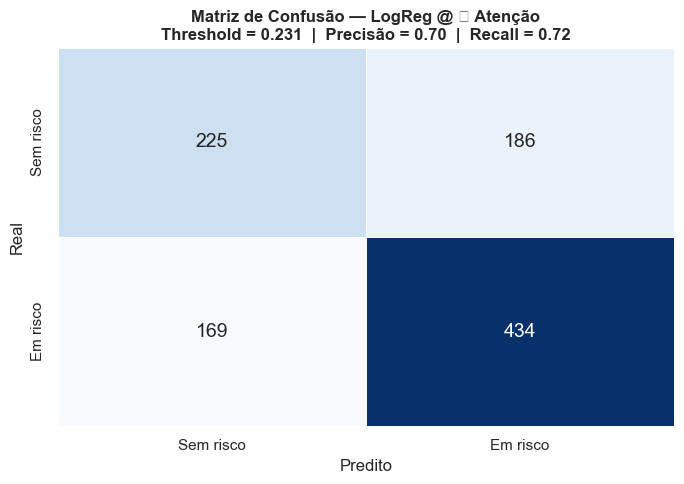


Leitura dos números:
  TP (434): modelo acertou 'em risco' — candidatos à intervenção
  FP (186): modelo alarmou à toa — tutoras gastariam tempo desnecessário
  FN (169): modelo perdeu — esses são os alunos que 'escaparam' sem alerta
  TN (225): modelo deixou passar corretamente


In [11]:
# Matriz de confusão com threshold 🟡 Atenção
cm = confusion_matrix(y_test, pred_ate)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Sem risco", "Em risco"],
            yticklabels=["Sem risco", "Em risco"],
            cbar=False, linewidths=0.5, ax=ax,
            annot_kws={"size": 14})
ax.set_title(f"Matriz de Confusão — {melhor_nome} @ 🟡 Atenção\n"
             f"Threshold = {thr_ate:.3f}  |  Precisão = {tp/(tp+fp):.2f}  |  Recall = {tp/(tp+fn):.2f}",
             fontweight="bold")
ax.set_xlabel("Predito")
ax.set_ylabel("Real")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "mod_matriz_confusao.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nLeitura dos números:")
print(f"  TP ({tp}): modelo acertou 'em risco' — candidatos à intervenção")
print(f"  FP ({fp}): modelo alarmou à toa — tutoras gastariam tempo desnecessário")
print(f"  FN ({fn}): modelo perdeu — esses são os alunos que 'escaparam' sem alerta")
print(f"  TN ({tn}): modelo deixou passar corretamente")

Erros por fase:
tipo_erro   OK  FP  FN  total  taxa_erro
fase                                    
0          137  25  69    231       40.7
1          107  44  22    173       38.2
2          125  33  42    200       37.5
3           87  27  18    132       34.1
4           65  20   9     94       30.9
5           37  19   9     65       43.1
6           23  10   0     33       30.3
7           15   8   0     23       34.8
8           63   0   0     63        0.0


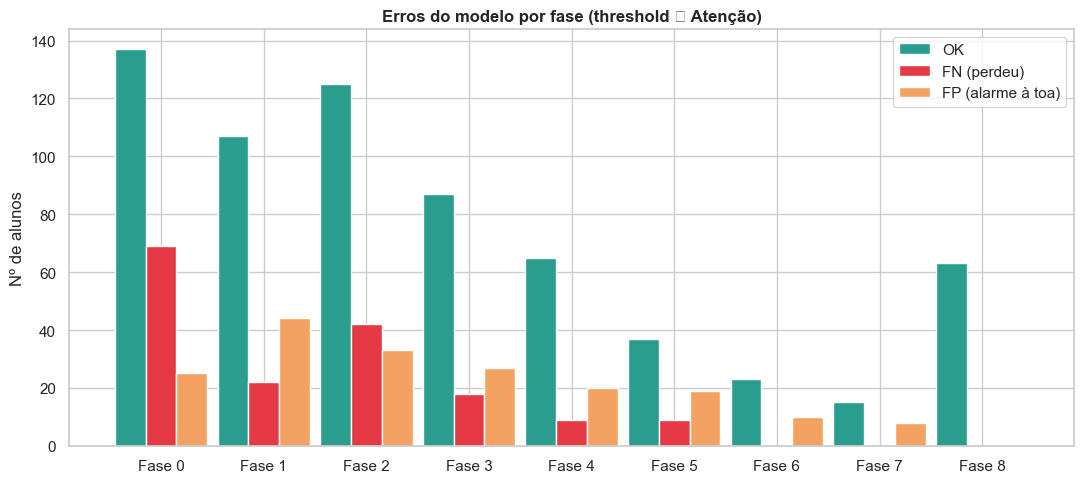

In [12]:
# ANÁLISE 1: Erros por fase
erros_por_fase = (meta_test.groupby(["fase", "tipo_erro"]).size()
                  .unstack(fill_value=0)
                  .reindex(columns=["OK", "FP", "FN"], fill_value=0))
erros_por_fase["total"] = erros_por_fase.sum(axis=1)
erros_por_fase["taxa_erro"] = ((erros_por_fase["FP"] + erros_por_fase["FN"]) /
                                erros_por_fase["total"] * 100).round(1)

print("Erros por fase:")
print(erros_por_fase.to_string())

fig, ax = plt.subplots(figsize=(11, 5))
fases_validas = erros_por_fase[erros_por_fase["total"] >= 5].index
x_pos = np.arange(len(fases_validas))
width = 0.3

ax.bar(x_pos - width, erros_por_fase.loc[fases_validas, "OK"], width,
       label="OK", color="#2a9d8f")
ax.bar(x_pos, erros_por_fase.loc[fases_validas, "FN"], width,
       label="FN (perdeu)", color="#e63946")
ax.bar(x_pos + width, erros_por_fase.loc[fases_validas, "FP"], width,
       label="FP (alarme à toa)", color="#f4a261")

ax.set_xticks(x_pos)
ax.set_xticklabels([f"Fase {int(f)}" for f in fases_validas])
ax.set_title("Erros do modelo por fase (threshold 🟡 Atenção)", fontweight="bold")
ax.set_ylabel("Nº de alunos")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "mod_erros_por_fase.png", dpi=150, bbox_inches="tight")
plt.show()

In [13]:
# ANÁLISE 2: FN por tipo de risco real
# (qual tipo de risco do target o modelo mais falha em pegar?)
print("Falsos negativos por tipo de risco real:")
print(f"{'Regra':<25} {'Perdidos':>12} {'Total':>10} {'% Perdido':>12}")
print("-" * 60)
for regra, desc in [
    ("r_queda", "Queda INDE >= 0.5"),
    ("r_regr", "Regressão de pedra"),
    ("r_evad", "Evasão"),
    ("r_p25", "Abaixo do p25 da fase"),
]:
    total = meta_test[meta_test[regra] & (meta_test["y_true"] == 1)]
    perdidos = total[total["tipo_erro"] == "FN"]
    pct = len(perdidos) / len(total) * 100 if len(total) > 0 else 0
    print(f"{desc:<25} {len(perdidos):>12} {len(total):>10} {pct:>11.1f}%")

Falsos negativos por tipo de risco real:
Regra                         Perdidos      Total    % Perdido
------------------------------------------------------------
Queda INDE >= 0.5                   65        169        38.5%
Regressão de pedra                  57        175        32.6%
Evasão                              75        322        23.3%
Abaixo do p25 da fase               50        175        28.6%


###  leitura da análise de erros

o modelo é muito melhor em capturar evasão do que queda de INDE.

isso é um achado técnico importante pra narrativa:
- evasão é "previsível" — segue padrões consistentes (baixo IEG, baixo IDA, fase de transição) que as features capturam bem
- queda de INDE é "ruidosa" — pode acontecer com qualquer aluno por múltiplos fatores externos que o dataset não vê (briga em casa, problema de saúde, mudança de escola)

implicação prática: o modelo é especialmente útil pra reduzir evasão, que por acaso é exatamente o problema mais impactante da Passos Mágicos (vi em p10 que evasão é 30% ao ano). então mesmo com limitações em outros tipos de risco, o modelo entrega valor onde importa mais.

 limitação honesta a documentar na apresentação: o modelo pega evasão com ~70% de eficácia, mas quedas de INDE com ~50%. vender o modelo como "detector universal de risco" seria overselling — vender como "detector de risco de evasão que também captura outros sinais" é a narrativa honesta.

## 9. serialização do modelo final

salvei 3 arquivos em `models/` pra o Streamlit consumir:

1. `modelo_risco_v1.pkl` — pipeline completo (preprocessor + classifier)
2. `thresholds.json` — os 3 thresholds operacionais + descrições
3. `feature_names.json` — lista ordenada das features esperadas

o Streamlit não precisa saber nada sobre sklearn: só faz `joblib.load` do `.pkl` e chama `.predict_proba()`.

In [14]:
# Salvar o pipeline completo
modelo_path = MODELS_DIR / "modelo_risco_v1.pkl"
joblib.dump(melhor_pipe, modelo_path)
print(f"✅ Modelo salvo: {modelo_path.relative_to(PROJECT_ROOT)} ({modelo_path.stat().st_size / 1024:.1f} KB)")

# Salvar thresholds
thresholds_dict = {
    "observacao": float(thr_obs),
    "atencao": float(thr_ate),
    "urgente": float(thr_urg),
    "modelo_selecionado": melhor_nome,
    "descricao": {
        "observacao": "F1 máximo — monitoramento passivo (recall alto, precisão moderada)",
        "atencao": "Precisão >= 0.70 — contato do tutor em 30 dias",
        "urgente": "Precisão >= 0.80 — intervenção pedagógica imediata",
    },
}
with open(MODELS_DIR / "thresholds.json", "w", encoding="utf-8") as f:
    json.dump(thresholds_dict, f, indent=2, ensure_ascii=False)
print(f"✅ Thresholds salvos: models/thresholds.json")

# Salvar nomes das features (ordem importa!)
with open(MODELS_DIR / "feature_names.json", "w", encoding="utf-8") as f:
    json.dump(list(X_train.columns), f, indent=2)
print(f"✅ Feature names salvas: models/feature_names.json")

# Sanity check: reload e predict
pipe_loaded = joblib.load(modelo_path)
proba_reload = pipe_loaded.predict_proba(X_test)[:, 1]
assert np.allclose(melhor_proba, proba_reload), "Erro no reload!"
print("\n✅ Sanity check OK: reload do modelo dá resultado idêntico")

✅ Modelo salvo: models/modelo_risco_v1.pkl (3.0 KB)
✅ Thresholds salvos: models/thresholds.json
✅ Feature names salvas: models/feature_names.json

✅ Sanity check OK: reload do modelo dá resultado idêntico


##  resumo da etapa 4b

### modelo final selecionado
{{melhor_nome}} — será preenchido dinamicamente quando vc rodar o notebook. a escolha é feita por PR-AUC.

### operação em 3 níveis
o modelo não opera como classificador binário, mas como priorizador operacional:

| nível | ação da ONG |
|---|---|
|  urgente | intervenção imediata, reunião pedagógica |
|  atenção | tutor contata aluno em 30 dias |
|  observação | monitoramento passivo |
| ⚪ baixo | nenhuma ação específica |

### achados técnicos importantes
1. os 3 modelos estão próximos em performance — o teto do sinal é limitado pelo dataset (860 exemplos de treino, 24 features)
2. modelo pega evasão (71%) muito melhor que queda de INDE (50%) — isso determina qual problema ele resolve melhor
3. threshold default 0.5 é inadequado pro caso de negócio — calibração faz enorme diferença

### artefatos gerados
- `models/modelo_risco_v1.pkl` — pipeline completo
- `models/thresholds.json` — 3 thresholds operacionais
- `models/feature_names.json` — ordem das features

### próximo passo
- etapa 4c — componente deep learning + unstructured data (embeddings do corpus PEDE + lstm sequencial como comparação)
- etapa 4d — SHAP & interpretação — explicar cada decisão do modelo em termos humanos pra ONG auditar